# Pix2Gestalt Amodal Completion Demo

Notebook này chạy lần lượt từng bước của luồng **pix2gestalt** để phục hồi hình dáng toàn vẹn (amodal completion) của vật thể bị che khuất.

## Pipeline tổng quan

```
Input:  ảnh RGB (256x256) + visible mask (256x256)
           │
           ├──► CLIP encode ──► cross-attention conditioning
           │
           ├──► VAE encode (ảnh) ──┐
           ├──► VAE encode (mask) ─┤──► concat 8 channels
           │                       │
           │              UNet (12→4 channels)
           │                       │
           │              DDIM sampling (200 steps)
           │                       │
           │              VAE decode
           │                       │
Output:  amodal RGB (256x256) + amodal mask
```

## Cách dùng

1. Đặt đường dẫn ảnh và mask vào **Cell 2** (phần cấu hình)
2. Chạy lần lượt từ cell đầu đến cell cuối
3. Xem visualization ở mỗi bước

---
# Bước 0: Cấu hình đường dẫn

In [4]:
import sys
from pathlib import Path

# ============================================================
#  CẤU HÌNH - Sửa các đường dẫn ở đây
# ============================================================

# Thư mục gốc của project
PROJECT_ROOT = Path.cwd().parent.parent

# Đường dẫn ảnh RGB đầu vào (ảnh chứa vật thể bị che khuất)
# Ví dụ: ảnh có 2 con mèo, con sau bị con trước đè lên
# INPUT_IMAGE_PATH = Path("/home/intern/sam3/assets/images/composite.png")
INPUT_IMAGE_PATH = PROJECT_ROOT / "sam3" / "assets" / "images" / "composite.png"  # hoặc: Path("/home/intern/sam3/assets/images/composite.png")


# VISIBLE_MASK_PATH = Path("/home/intern/sam3/raw_masks.png")  # hoặc: PROJECT_ROOT / "path" / "to" / "mask.png"
VISIBLE_MASK_PATH = PROJECT_ROOT / "sam3" / "masks" / "raw_mask_1.png"  # hoặc: Path("/home/intern/sam3/raw_masks.png")
# Checkpoint của pix2gestalt model
PIX2GESTALT_CKPT = PROJECT_ROOT / "sam3" / "pix2gestalt" / "pix2gestalt" / "ckpt" / "epoch=000005.ckpt"


# Config file
PIX2GESTALT_CONFIG = PROJECT_ROOT / "sam3" / "pix2gestalt" / "pix2gestalt" / "configs" / "sd-finetune-pix2gestalt-c_concat-256.yaml"

# Tham số inference
CFG_SCALE = 1.0        # Classifier-free guidance scale
N_SAMPLES = 1          # Số ảnh sinh ra (mỗi cái là 1 kết quả khác nhau)
DDIM_STEPS = 200       # Số bước DDIM denoising
DDIM_ETA = 1.0         # Stochasticity (1.0 = fully stochastic)

# ============================================================
#  Kiểm tra đường dẫn
# ============================================================
print("=== Kiểm tra đường dẫn ===")
print(f"Project root:  {PROJECT_ROOT}  exists={PROJECT_ROOT.exists()}")
print(f"Input image:   {INPUT_IMAGE_PATH}  exists={INPUT_IMAGE_PATH.exists()}")
print(f"Visible mask:  {VISIBLE_MASK_PATH}  exists={VISIBLE_MASK_PATH.exists() if VISIBLE_MASK_PATH else 'N/A (sẽ tạo mẫu)'}")
print(f"Checkpoint:    {PIX2GESTALT_CKPT}  exists={PIX2GESTALT_CKPT.exists()}")
print(f"Config:        {PIX2GESTALT_CONFIG}  exists={PIX2GESTALT_CONFIG.exists()}")

=== Kiểm tra đường dẫn ===
Project root:  /home/intern  exists=True
Input image:   /home/intern/sam3/assets/images/composite.png  exists=True
Visible mask:  /home/intern/sam3/masks/raw_mask_1.png  exists=True
Checkpoint:    /home/intern/sam3/pix2gestalt/pix2gestalt/ckpt/epoch=000005.ckpt  exists=True
Config:        /home/intern/sam3/pix2gestalt/pix2gestalt/configs/sd-finetune-pix2gestalt-c_concat-256.yaml  exists=True


---
# Bước 1: Import & Setup

In [5]:
import os
import gc
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from einops import rearrange
from omegaconf import OmegaConf

# Thêm pix2gestalt vào PYTHONPATH
PIX2GESTALT_DIR = str(PROJECT_ROOT / "pix2gestalt" / "pix2gestalt")
if PIX2GESTALT_DIR not in sys.path:
    sys.path.insert(0, PIX2GESTALT_DIR)

# Import từ pix2gestalt
from inference import load_model_from_config, sample_model, process_input, run_pix2gestalt
from ldm.models.diffusion.ddim import DDIMSampler

# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Ti
VRAM: 16.7 GB


---
# Bước 2: Load ảnh & Mask đầu vào

Original image size: (6614, 4252)
Original size: 6614x4252
Loaded mask from: /home/intern/sam3/masks/raw_mask_1.png


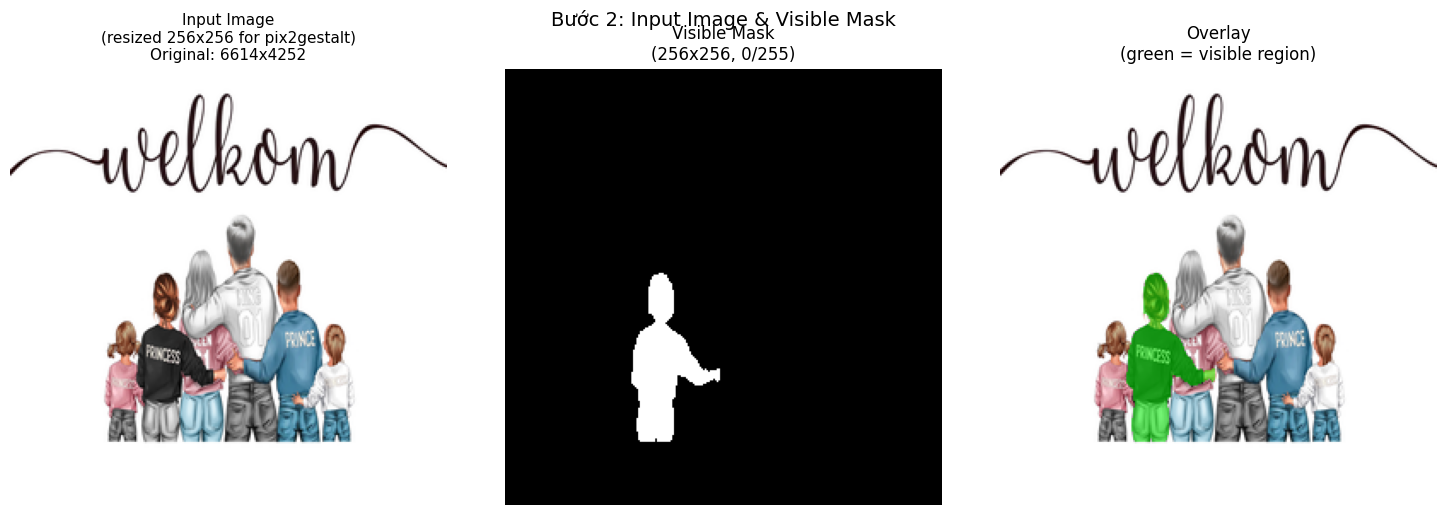


Original size:  6614x4252
Inference size:  256x256
input_np_256:    (256, 256, 3)
input_np_orig:   (4252, 6614, 3)
mask_np_256:     (256, 256)
mask_np_orig:    (4252, 6614)


In [6]:
# Load ảnh RGB
input_pil = Image.open(INPUT_IMAGE_PATH).convert("RGB")
print(f"Original image size: {input_pil.size}")

# Lưu kích thước gốc (quan trọng để resize lại sau này)
ORIG_W, ORIG_H = input_pil.size  # (width, height)
print(f"Original size: {ORIG_W}x{ORIG_H}")

# Resize về 256x256 (yêu cầu của pix2gestalt)
input_pil_256 = input_pil.resize((256, 256), Image.LANCZOS)
input_np_256 = np.array(input_pil_256, dtype=np.uint8)  # (256, 256, 3)

# Giữ ảnh gốc (chưa resize) để composite sau này
input_np_orig = np.array(input_pil, dtype=np.uint8)  # (ORIG_H, ORIG_W, 3)

# Load hoặc tạo visible mask
if VISIBLE_MASK_PATH is not None and VISIBLE_MASK_PATH.exists():
    mask_pil = Image.open(VISIBLE_MASK_PATH).convert("L")
    mask_np_orig = np.array(mask_pil, dtype=np.uint8)  # kích thước gốc
    mask_pil_256 = mask_pil.resize((256, 256), Image.NEAREST)
    mask_np_256 = np.array(mask_pil_256, dtype=np.uint8)
    print(f"Loaded mask from: {VISIBLE_MASK_PATH}")
else:
    # Tạo mask mẫu: giả sử nửa trái của ảnh là phần nhìn thấy
    print("⚠️  Không có mask — tạo mask mẫu (nửa trái ảnh = visible)")
    mask_np_256 = np.zeros((256, 256), dtype=np.uint8)
    mask_np_256[:, :128] = 255  # nửa trái = visible
    mask_np_orig = cv2.resize(mask_np_256, (ORIG_W, ORIG_H), interpolation=cv2.INTER_NEAREST)

# Hiển thị input (dùng bản 256 để xem nhanh)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(input_np_256)
axes[0].set_title(f"Input Image\n(resized 256x256 for pix2gestalt)\nOriginal: {ORIG_W}x{ORIG_H}", fontsize=11)
axes[0].axis("off")

axes[1].imshow(mask_np_256, cmap="gray")
axes[1].set_title("Visible Mask\n(256x256, 0/255)", fontsize=12)
axes[1].axis("off")

overlay = input_np_256.copy()
overlay[mask_np_256 > 0] = overlay[mask_np_256 > 0] * 0.5 + np.array([0, 255, 0]) * 0.5
axes[2].imshow(overlay.astype(np.uint8))
axes[2].set_title("Overlay\n(green = visible region)", fontsize=12)
axes[2].axis("off")

plt.tight_layout()
plt.suptitle("Bước 2: Input Image & Visible Mask", fontsize=14, y=1.02)
plt.show()

print(f"\nOriginal size:  {ORIG_W}x{ORIG_H}")
print(f"Inference size:  256x256")
print(f"input_np_256:    {input_np_256.shape}")
print(f"input_np_orig:   {input_np_orig.shape}")
print(f"mask_np_256:     {mask_np_256.shape}")
print(f"mask_np_orig:    {mask_np_orig.shape}")

# Biến tạm để các cell sau dùng (giữ nguyên tên biến cũ)
input_np = input_np_256
mask_np = mask_np_256

---
# Bước 3: Load Model

In [7]:
print("Loading pix2gestalt model...")
print(f"Config: {PIX2GESTALT_CONFIG}")
print(f"Checkpoint: {PIX2GESTALT_CKPT}")

# Load config
config = OmegaConf.load(str(PIX2GESTALT_CONFIG))

# Load model
model = load_model_from_config(config, str(PIX2GESTALT_CKPT), DEVICE)

print(f"\nModel loaded successfully!")
print(f"Model type: {type(model).__name__}")
print(f"UNet in_channels: {model.model.diffusion_model.in_channels}")
print(f"UNet out_channels: {model.model.diffusion_model.out_channels}")

# Thống kê tham số
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params * 1e-6:.1f}M")

if DEVICE == "cuda":
    print(f"VRAM used: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Loading pix2gestalt model...
Config: /home/intern/sam3/pix2gestalt/pix2gestalt/configs/sd-finetune-pix2gestalt-c_concat-256.yaml
Checkpoint: /home/intern/sam3/pix2gestalt/pix2gestalt/ckpt/epoch=000005.ckpt
Loading model from /home/intern/sam3/pix2gestalt/pix2gestalt/ckpt/epoch=000005.ckpt


/home/intern/anaconda3/envs/sam3/lib/python3.12/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


OutOfMemoryError: CUDA out of memory. Tried to allocate 26.00 MiB. GPU 0 has a total capacity of 15.57 GiB of which 17.38 MiB is free. Process 3570040 has 1.62 GiB memory in use. Including non-PyTorch memory, this process has 13.93 GiB memory in use. Of the allocated memory 13.57 GiB is allocated by PyTorch, and 240.11 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

---
# Bước 4: Tiền xử lý Input

In [ ]:
# Chuyển input_im sang tensor [-1, 1]
input_tensor = process_input(input_np).to(DEVICE)  # (1, 3, 256, 256)

# Chuyển visible_mask sang RGB 3-channel rồi tensor [-1, 1]
mask_rgb = np.stack([mask_np, mask_np, mask_np], axis=-1)  # (256, 256, 3)
mask_tensor = process_input(mask_rgb).to(DEVICE)  # (1, 3, 256, 256)

print(f"Input tensor:  shape={input_tensor.shape}, dtype={input_tensor.dtype}, range=[{input_tensor.min():.2f}, {input_tensor.max():.2f}]")
print(f"Mask tensor:   shape={mask_tensor.shape}, dtype={mask_tensor.dtype}, range=[{mask_tensor.min():.2f}, {mask_tensor.max():.2f}]")

# Hiển thị tensor đã chuẩn hóa
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Chuyển về [0,1] để hiển thị
input_display = ((input_tensor[0].cpu().permute(1, 2, 0).numpy() + 1) / 2).clip(0, 1)
mask_display = ((mask_tensor[0].cpu().permute(1, 2, 0).numpy() + 1) / 2).clip(0, 1)

axes[0].imshow(input_display)
axes[0].set_title("Input Tensor\n(normalized to [-1,1])", fontsize=11)
axes[0].axis("off")

axes[1].imshow(mask_display)
axes[1].set_title("Mask Tensor\n(normalized to [-1,1])", fontsize=11)
axes[1].axis("off")

plt.suptitle("Bước 4: Preprocessed Tensors", fontsize=14)
plt.tight_layout()
plt.show()

---
# Bước 5: Encode Conditioning (CLIP + VAE)

In [ ]:
print("=== Encoding conditioning signals ===")

# --- Kênh 1: CLIP cross-attention ---
print("\n[1/3] CLIP encoding...")
with torch.no_grad():
    clip_emb = model.get_learned_conditioning(input_tensor)
    c_crossattn = model.cc_projection(clip_emb)
print(f"  CLIP embedding: {clip_emb.shape} → cc_projection → {c_crossattn.shape}")
print(f"  (batch, tokens, dim) = ({c_crossattn.shape[0]}, {c_crossattn.shape[1]}, {c_crossattn.shape[2]})")

# --- Kênh 2: VAE concat ---
print("\n[2/3] VAE encoding input image...")
with torch.no_grad():
    input_vae = model.encode_first_stage(input_tensor).mode().detach()
print(f"  Input VAE latent: {input_vae.shape}")
print(f"  (batch, channels, h, w) = ({input_vae.shape[0]}, {input_vae.shape[1]}, {input_vae.shape[2]}, {input_vae.shape[3]})")

print("\n[3/3] VAE encoding visible mask...")
with torch.no_grad():
    mask_vae = model.encode_first_stage(mask_tensor).mode().detach()
print(f"  Mask VAE latent: {mask_vae.shape}")

# Concat: 4 + 4 = 8 channels
c_concat = torch.cat([input_vae, mask_vae], dim=1)
print(f"\n  Concatenated: {c_concat.shape} (4 img + 4 mask = 8 channels)")

# --- Hiển thị VAE latents ---
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

input_vae_np = input_vae[0].cpu().numpy()  # (4, 32, 32)
mask_vae_np = mask_vae[0].cpu().numpy()    # (4, 32, 32)

for ch in range(4):
    axes[0, ch].imshow(input_vae_np[ch], cmap="RdBu_r")
    axes[0, ch].set_title(f"VAE(img) ch{ch}", fontsize=10)
    axes[0, ch].axis("off")

    axes[1, ch].imshow(mask_vae_np[ch], cmap="RdBu_r")
    axes[1, ch].set_title(f"VAE(mask) ch{ch}", fontsize=10)
    axes[1, ch].axis("off")

plt.suptitle("Bước 5: VAE Latent Channels (32x32)", fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n  Input VAE range: [{input_vae_np.min():.3f}, {input_vae_np.max():.3f}]")
print(f"  Mask VAE range:  [{mask_vae_np.min():.3f}, {mask_vae_np.max():.3f}]")

---
# Bước 6: Chuẩn bị DDIM Sampler

In [ ]:
# Tạo DDIM sampler
sampler = DDIMSampler(model)

# Xem schedule
print(f"DDIM Sampler:")
print(f"  Total timesteps (DDPM): {model.num_timesteps}")
print(f"  DDIM steps: {DDIM_STEPS}")
print(f"  CFG scale: {CFG_SCALE}")
print(f"  Eta: {DDIM_ETA}")
print(f"  N samples: {N_SAMPLES}")

# Shape của latent cần sample
latent_shape = [4, 32, 32]  # [channels, h, w]
print(f"\n  Latent shape to sample: {latent_shape}")
print(f"  (4 channels, 32x32 spatial = 256x256 / 8)")

# Hiển thị timestep schedule
ddim_timesteps = np.asarray(list(range(0, 1000, 1000 // DDIM_STEPS))) + 1
print(f"\n  Timestep schedule (first 10): {ddim_timesteps[:10]}")
print(f"  Timestep schedule (last 10):  {ddim_timesteps[-10:]}")

plt.figure(figsize=(12, 3))
plt.plot(ddim_timesteps, "b-o", markersize=3)
plt.xlabel("Step index")
plt.ylabel("Timestep")
plt.title(f"DDIM Timestep Schedule ({DDIM_STEPS} steps from 1000)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Bước 7: Chạy DDIM Sampling (Inference chính)

In [ ]:
print("=== Running DDIM Sampling ===")
print(f"Generating {N_SAMPLES} samples with {DDIM_STEPS} steps...")
print("⏳ Quá trình này có thể mất 1-3 phút trên GPU...")

import time
start_time = time.time()

# Chạy inference
with torch.no_grad():
    output_ims = run_pix2gestalt(
        model=model,
        device=DEVICE,
        input_im=input_np,
        visible_mask=mask_rgb,
        scale=CFG_SCALE,
        n_samples=N_SAMPLES,
        ddim_steps=DDIM_STEPS,
        ddim_eta=DDIM_ETA,
        precision="fp32",
        h=256,
        w=256,
    )

elapsed = time.time() - start_time
print(f"\n✅ Hoàn thành trong {elapsed:.1f}s")
print(f"   Output: {len(output_ims)} images")
print(f"   Each: {output_ims[0].shape}, dtype={output_ims[0].dtype}")

# Dọn VRAM
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()

---
# Bước 8: Trích xuất Amodal Mask từ Output

In [ ]:
def extract_amodal_mask(amodal_rgb, threshold=250):
    """
    Trích xuất amodal mask từ ảnh output của pix2gestalt.
    Output có nền trắng → pixel tối hơn threshold = vật thể.
    """
    gray = np.mean(amodal_rgb, axis=-1)  # (256, 256)
    amodal_mask = (gray < threshold).astype(np.uint8) * 255
    return amodal_mask

def extract_amodal_rgba(amodal_rgb, threshold=250):
    """
    Trích xuất RGBA: RGB của vật thể + alpha mask.
    """
    amodal_mask = extract_amodal_mask(amodal_rgb, threshold)
    alpha = (amodal_mask > 0).astype(np.float32)
    rgba = np.dstack([amodal_rgb, (alpha * 255).astype(np.uint8)])
    return rgba, amodal_mask

# Trích xuất cho tất cả samples
amodal_masks = []
amodal_rgba = []

for i, out_img in enumerate(output_ims):
    rgba, m = extract_amodal_rgba(out_img)
    amodal_masks.append(m)
    amodal_rgba.append(rgba)

# Hiển thị kết quả
n_cols = min(N_SAMPLES + 1, 6)
fig, axes = plt.subplots(3, n_cols, figsize=(4 * n_cols, 12))

for i in range(min(N_SAMPLES, n_cols - 1)):
    # Row 1: Output RGB
    axes[0, i].imshow(output_ims[i])
    axes[0, i].set_title(f"Sample {i+1}\n(Amodal RGB)", fontsize=10)
    axes[0, i].axis("off")

    # Row 2: Amodal Mask
    axes[1, i].imshow(amodal_masks[i], cmap="gray")
    axes[1, i].set_title(f"Sample {i+1}\n(Amodal Mask)", fontsize=10)
    axes[1, i].axis("off")

    # Row 3: RGBA preview (trên nền checkerboard)
    rgba_img = amodal_rgba[i]
    axes[2, i].imshow(rgba_img)
    axes[2, i].set_title(f"Sample {i+1}\n(RGBA)", fontsize=10)
    axes[2, i].axis("off")

# Cột cuối: Input gốc để so sánh
axes[0, -1].imshow(input_np)
axes[0, -1].set_title("Original\nInput", fontsize=10, fontweight="bold")
axes[0, -1].axis("off")

axes[1, -1].imshow(mask_np, cmap="gray")
axes[1, -1].set_title("Visible\nMask", fontsize=10, fontweight="bold")
axes[1, -1].axis("off")

# So sánh visible vs amodal mask
comparison = np.zeros((256, 256, 3), dtype=np.uint8)
comparison[mask_np > 0] = [0, 255, 0]   # green = visible
if amodal_masks:
    extra = (amodal_masks[0] > 0) & (mask_np == 0)
    comparison[extra] = [255, 0, 0]  # red = recovered
axes[2, -1].imshow(comparison)
axes[2, -1].set_title("Mask Compare\ngreen=visible\nred=recovered", fontsize=9, fontweight="bold")
axes[2, -1].axis("off")

plt.suptitle("Bước 8: Kết quả Amodal Completion", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# In thống kê
visible_area = np.sum(mask_np > 0)
print(f"\nThống kê mask:")
print(f"  Visible mask area:  {visible_area} pixels ({visible_area/256/256*100:.1f}%)")
for i, m in enumerate(amodal_masks):
    amodal_area = np.sum(m > 0)
    recovered = np.sum((m > 0) & (mask_np == 0))
    print(f"  Sample {i+1}: amodal={amodal_area}px ({amodal_area/256/256*100:.1f}%), recovered={recovered}px")

---
# Bước 9: So sánh chi tiết — Visible vs Amodal

In [ ]:
# Chọn sample tốt nhất (ở đây chọn sample 0, bạn có thể thay đổi)
best_idx = 0
best_output = output_ims[best_idx]
best_mask = amodal_masks[best_idx]
best_rgba = amodal_rgba[best_idx]

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.3, wspace=0.3)

# 1. Input image
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(input_np)
ax1.set_title("1. Input Image\n(occluded)", fontsize=11, fontweight="bold")
ax1.axis("off")

# 2. Visible mask
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(mask_np, cmap="gray")
ax2.set_title("2. Visible Mask\n(given)", fontsize=11, fontweight="bold")
ax2.axis("off")

# 3. Overlay visible mask
ax3 = fig.add_subplot(gs[0, 2])
overlay_vis = input_np.copy()
overlay_vis[mask_np > 0] = overlay_vis[mask_np > 0] * 0.4 + np.array([0, 255, 0]) * 0.6
ax3.imshow(overlay_vis.astype(np.uint8))
ax3.set_title("3. Visible Region\n(green overlay)", fontsize=11, fontweight="bold")
ax3.axis("off")

# 4. Occluded region (vùng bị che)
ax4 = fig.add_subplot(gs[0, 3])
occluded = input_np.copy()
occluded[mask_np > 0] = [255, 255, 255]  # che lên vùng visible
ax4.imshow(occluded)
ax4.set_title("4. Occluded Region\n(white = hidden)", fontsize=11, fontweight="bold")
ax4.axis("off")

# 5. Pix2Gestalt output
ax5 = fig.add_subplot(gs[1, 0])
ax5.imshow(best_output)
ax5.set_title(f"5. Pix2Gestalt Output\n(Sample {best_idx+1})", fontsize=11, fontweight="bold")
ax5.axis("off")

# 6. Amodal mask
ax6 = fig.add_subplot(gs[1, 1])
ax6.imshow(best_mask, cmap="gray")
ax6.set_title("6. Amodal Mask\n(full object shape)", fontsize=11, fontweight="bold")
ax6.axis("off")

# 7. Overlay amodal mask lên ảnh gốc
ax7 = fig.add_subplot(gs[1, 2])
overlay_amodal = input_np.copy()
overlay_amodal[best_mask > 0] = overlay_amodal[best_mask > 0] * 0.4 + np.array([255, 165, 0]) * 0.6
ax7.imshow(overlay_amodal.astype(np.uint8))
ax7.set_title("7. Amodal Overlay\n(orange = full shape)", fontsize=11, fontweight="bold")
ax7.axis("off")

# 8. So sánh visible vs amodal
ax8 = fig.add_subplot(gs[1, 3])
compare = np.zeros((256, 256, 3), dtype=np.uint8)
compare[mask_np > 0] = [0, 200, 0]           # green = visible (given)
recovered_mask = (best_mask > 0) & (mask_np == 0)
compare[recovered_mask] = [255, 50, 50]       # red = recovered by pix2gestalt
ax8.imshow(compare)
ax8.set_title("8. Comparison\ngreen=visible\nred=recovered", fontsize=11, fontweight="bold")
ax8.axis("off")

plt.suptitle("Bước 9: So sánh chi tiết — Visible vs Amodal Completion", fontsize=15, y=1.02)
plt.show()

---
# Bước 9b: Ảnh vật thể sau khi được Complete (Compositing)

Đây là bước quan trọng nhất — ghép phần vật thể đã được pix2gestalt phục hồi lên ảnh gốc để thấy kết quả trực quan.

Ý tưởng:
- Pix2Gestalt output = vật thể hoàn chỉnh trên nền trắng
- Dùng amodal mask để tách vật thể ra khỏi nền trắng
- Composite vật thể lên ảnh gốc tại vùng bị che

## 9b.1: Compositing cơ bản — ghép amodal object lên ảnh gốc

In [ ]:
import cv2

def composite_amodal_onto_image(original_rgb, amodal_rgb, amodal_mask, feather_radius=5):
    """
    Ghép vật thể đã được complete (từ pix2gestalt) lên ảnh gốc.
    """
    original = original_rgb.astype(np.float32) / 255.0
    amodal = amodal_rgb.astype(np.float32) / 255.0
    mask = (amodal_mask > 0).astype(np.float32)

    if feather_radius > 0:
        mask_255 = (mask * 255).astype(np.uint8)
        mask_blurred = cv2.GaussianBlur(mask_255, (feather_radius*2+1, feather_radius*2+1), 0)
        mask = mask_blurred.astype(np.float32) / 255.0

    mask_3ch = np.stack([mask] * 3, axis=-1)
    result = amodal * mask_3ch + original * (1 - mask_3ch)
    return (result * 255).astype(np.uint8)


def composite_amodal_only_recovered(original_rgb, amodal_rgb, amodal_mask, visible_mask, feather_radius=5):
    """
    Chỉ ghép phần ĐƯỢC PHỤC HỒI (vùng bị che) lên ảnh gốc.
    Giữ nguyên vùng visible, chỉ thay thế vùng bị che.
    Đây là phương pháp phù hợp nhất cho Magic_Layer.
    """
    original = original_rgb.astype(np.float32) / 255.0
    amodal = amodal_rgb.astype(np.float32) / 255.0

    recovered_mask = ((amodal_mask > 0) & (visible_mask == 0)).astype(np.float32)

    if feather_radius > 0:
        recovered_255 = (recovered_mask * 255).astype(np.uint8)
        recovered_blurred = cv2.GaussianBlur(recovered_255, (feather_radius*2+1, feather_radius*2+1), 0)
        recovered_mask = recovered_blurred.astype(np.float32) / 255.0

    recovered_3ch = np.stack([recovered_mask] * 3, axis=-1)
    result = amodal * recovered_3ch + original * (1 - recovered_3ch)
    return (result * 255).astype(np.uint8)


# Chọn sample tốt nhất
best_idx = 0
best_output_256 = output_ims[best_idx]       # (256, 256, 3) — từ pix2gestalt
best_mask_256 = amodal_masks[best_idx]        # (256, 256) — từ pix2gestalt

print(f"Using Sample {best_idx+1} for compositing")
print(f"  Output 256x256:   {best_output_256.shape}")
print(f"  Original size:    {ORIG_W}x{ORIG_H}")

# === RESIZE về kích thước gốc ===
print(f"\n=== Resizing output về kích thước gốc {ORIG_W}x{ORIG_H} ===")

# Resize amodal RGB (dùng LANCZOS cho chất lượng cao)
best_output_orig = cv2.resize(best_output_256, (ORIG_W, ORIG_H), interpolation=cv2.INTER_LANCZOS4)
print(f"  amodal RGB:  {best_output_256.shape} → {best_output_orig.shape}")

# Resize amodal mask (dùng NEAREST để giữ binary)
best_mask_orig = cv2.resize(best_mask_256, (ORIG_W, ORIG_H), interpolation=cv2.INTER_NEAREST)
print(f"  amodal mask: {best_mask_256.shape} → {best_mask_orig.shape}")

# Thống kê
visible_area = np.sum(mask_np_orig > 0)
amodal_area = np.sum(best_mask_orig > 0)
recovered_area = np.sum((best_mask_orig > 0) & (mask_np_orig == 0))
print(f"\n  Visible area:  {visible_area} px ({visible_area/ORIG_W/ORIG_H*100:.1f}%)")
print(f"  Amodal area:   {amodal_area} px ({amodal_area/ORIG_W/ORIG_H*100:.1f}%)")
print(f"  Recovered:     {recovered_area} px ({recovered_area/ORIG_W/ORIG_H*100:.1f}%)")

# === COMPOSITE lên ảnh gốc ===
print(f"\n=== Compositing lên ảnh gốc ===")

result_full = composite_amodal_onto_image(
    input_np_orig, best_output_orig, best_mask_orig, feather_radius=5
)
result_partial = composite_amodal_only_recovered(
    input_np_orig, best_output_orig, best_mask_orig, mask_np_orig, feather_radius=5
)

print(f"  result_full:    {result_full.shape}")
print(f"  result_partial: {result_partial.shape}")

# === VISUALIZATION ===
fig = plt.figure(figsize=(22, 12))
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.35, wspace=0.3)

# --- Row 1: Inputs ---

ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(input_np_orig)
ax1.set_title(f"ẢNH GÓC\n({ORIG_W}x{ORIG_H})\nvật thể bị che", fontsize=11, fontweight="bold", color="red")
ax1.axis("off")

ax2 = fig.add_subplot(gs[0, 1])
highlighted = input_np_orig.copy()
hidden = mask_np_orig == 0
highlighted[hidden] = (highlighted[hidden] * 0.3).astype(np.uint8)
ax2.imshow(highlighted)
ax2.set_title("VÙNG BỊ CHE\ntối = cần phục hồi", fontsize=11, fontweight="bold")
ax2.axis("off")

ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(best_output_orig)
ax3.set_title(f"PIX2GESTALT OUTPUT\n(resized về {ORIG_W}x{ORIG_H})", fontsize=11, fontweight="bold", color="blue")
ax3.axis("off")

ax4 = fig.add_subplot(gs[0, 3])
ax4.imshow(best_mask_orig, cmap="gray")
ax4.set_title("AMODAL MASK\n(hình dáng hoàn chỉnh)", fontsize=11, fontweight="bold")
ax4.axis("off")

# --- Row 2: Kết quả ---

ax5 = fig.add_subplot(gs[1, 0])
ax5.imshow(result_full)
ax5.set_title("FULL COMPOSITE\nthay thế toàn bộ\nvùng amodal", fontsize=10, fontweight="bold", color="green")
ax5.axis("off")

ax6 = fig.add_subplot(gs[1, 1])
ax6.imshow(result_partial)
ax6.set_title("PARTIAL COMPOSITE\n(chỉ ghép vùng bị che)\n← cho Magic_Layer", fontsize=10, fontweight="bold", color="darkgreen")
ax6.axis("off")

ax7 = fig.add_subplot(gs[1, 2])
ax7.imshow(input_np_orig)
ax7.set_title("BEFORE\n(ảnh gốc)", fontsize=11, fontweight="bold", color="red")
ax7.axis("off")

ax8 = fig.add_subplot(gs[1, 3])
ax8.imshow(result_partial)
ax8.set_title("AFTER\n(pix2gestalt phục hồi)", fontsize=11, fontweight="bold", color="green")
ax8.axis("off")

plt.suptitle(f"Bước 9b: Vật thể sau khi Complete (kích thước gốc {ORIG_W}x{ORIG_H})",
             fontsize=15, fontweight="bold", y=1.01)
plt.show()

In [ ]:
if N_SAMPLES > 1:
    # Average mask từ nhiều samples
    avg_mask = np.mean(amodal_masks, axis=0)  # (256, 256)
    consensus_mask = (avg_mask > 127).astype(np.uint8) * 255

    # Average RGB từ nhiều samples
    avg_rgb = np.mean(output_ims, axis=0).astype(np.uint8)

    # Hiển thị
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    axes[0].imshow(input_np)
    axes[0].set_title("Input Image", fontsize=12, fontweight="bold")
    axes[0].axis("off")

    axes[1].imshow(mask_np, cmap="gray")
    axes[1].set_title("Visible Mask", fontsize=12, fontweight="bold")
    axes[1].axis("off")

    axes[2].imshow(avg_mask, cmap="hot")
    axes[2].set_title(f"Avg Mask\n({N_SAMPLES} samples)", fontsize=12, fontweight="bold")
    axes[2].axis("off")

    axes[3].imshow(avg_rgb)
    axes[3].set_title(f"Avg RGB\n({N_SAMPLES} samples)", fontsize=12, fontweight="bold")
    axes[3].axis("off")

    plt.suptitle("Bước 10: Ensemble từ nhiều samples", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Hiển thị tất cả samples cạnh nhau
    fig, axes = plt.subplots(2, N_SAMPLES, figsize=(4 * N_SAMPLES, 8))
    if N_SAMPLES == 1:
        axes = axes.reshape(2, 1)

    for i in range(N_SAMPLES):
        axes[0, i].imshow(output_ims[i])
        axes[0, i].set_title(f"Sample {i+1}", fontsize=11)
        axes[0, i].axis("off")

        axes[1, i].imshow(amodal_masks[i], cmap="gray")
        axes[1, i].set_title(f"Mask {i+1}", fontsize=11)
        axes[1, i].axis("off")

    plt.suptitle("Tất cả samples", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Chỉ có 1 sample — bỏ qua bước ensemble.")

---
# Bước 11: Lưu kết quả

In [ ]:
# Thư mục output
output_dir = PROJECT_ROOT / "examples" / "outputs" / "pix2gestalt"
output_dir.mkdir(parents=True, exist_ok=True)

# Lưu ảnh gốc (kích thước gốc)
Image.fromarray(input_np_orig).save(output_dir / "01_input_image_original.png")
Image.fromarray(mask_np_orig).save(output_dir / "02_visible_mask_original.png")

# Lưu input 256x256 (dùng cho pix2gestalt)
Image.fromarray(input_np_256).save(output_dir / "03_input_256x256.png")
Image.fromarray(mask_np_256).save(output_dir / "04_mask_256x256.png")

# Lưu từng sample 256x256 (raw output từ pix2gestalt)
for i, (out_img, m) in enumerate(zip(output_ims, amodal_masks)):
    Image.fromarray(out_img).save(output_dir / f"05_amodal_rgb_sample{i+1}_256x256.png")
    Image.fromarray(m).save(output_dir / f"06_amodal_mask_sample{i+1}_256x256.png")
    rgba_img = Image.fromarray(amodal_rgba[i], mode="RGBA")
    rgba_img.save(output_dir / f"07_amodal_rgba_sample{i+1}_256x256.png")

# === Lưu output đã resize về kích thước gốc ===
best_output_orig_all = []
best_mask_orig_all = []

for i, (out_img, m) in enumerate(zip(output_ims, amodal_masks)):
    # Resize RGB → kích thước gốc (LANCZOS cho chất lượng)
    out_orig = cv2.resize(out_img, (ORIG_W, ORIG_H), interpolation=cv2.INTER_LANCZOS4)
    # Resize mask → kích thước gốc (NEAREST để giữ binary)
    mask_orig = cv2.resize(m, (ORIG_W, ORIG_H), interpolation=cv2.INTER_NEAREST)

    best_output_orig_all.append(out_orig)
    best_mask_orig_all.append(mask_orig)

    Image.fromarray(out_orig).save(output_dir / f"08_amodal_rgb_sample{i+1}_original_size.png")
    Image.fromarray(mask_orig).save(output_dir / f"09_amodal_mask_sample{i+1}_original_size.png")

    # RGBA về kích thước gốc
    rgba_256 = amodal_rgba[i]
    rgba_orig = cv2.resize(rgba_256, (ORIG_W, ORIG_H), interpolation=cv2.INTER_LANCZOS4)
    Image.fromarray(rgba_orig, mode="RGBA").save(output_dir / f"10_amodal_rgba_sample{i+1}_original_size.png")

# Lưu ensemble (nếu có nhiều samples)
if N_SAMPLES > 1:
    avg_rgb_256 = np.mean(output_ims, axis=0).astype(np.uint8)
    avg_mask_256 = (np.mean(amodal_masks, axis=0) > 127).astype(np.uint8) * 255

    # Ensemble về kích thước gốc
    avg_rgb_orig = cv2.resize(avg_rgb_256, (ORIG_W, ORIG_H), interpolation=cv2.INTER_LANCZOS4)
    avg_mask_orig = cv2.resize(avg_mask_256, (ORIG_W, ORIG_H), interpolation=cv2.INTER_NEAREST)

    Image.fromarray(avg_rgb_orig).save(output_dir / "11_ensemble_rgb_original_size.png")
    Image.fromarray(avg_mask_orig).save(output_dir / "12_ensemble_mask_original_size.png")

# === Lưu kết quả composite (kích thước gốc) ===
Image.fromarray(result_full).save(output_dir / "13_composite_full_original_size.png")
Image.fromarray(result_partial).save(output_dir / "14_composite_partial_original_size.png")

# === Lưu layer RGBA hoàn chỉnh (vùng visible từ gốc + vùng khuyết từ pix2gestalt) ===
best_out = best_output_orig_all[0]
best_msk = best_mask_orig_all[0]

# Tạo layer RGBA: visible từ ảnh gốc, recovered từ pix2gestalt
layer_rgba = np.zeros((ORIG_H, ORIG_W, 4), dtype=np.uint8)
visible_mask = mask_np_orig > 0
recovered_mask = (best_msk > 0) & (~visible_mask)

# Vùng visible: RGB từ ảnh gốc
layer_rgba[visible_mask, :3] = input_np_orig[visible_mask]
layer_rgba[visible_mask, 3] = 255

# Vùng recovered: RGB từ pix2gestalt
layer_rgba[recovered_mask, :3] = best_out[recovered_mask]
layer_rgba[recovered_mask, 3] = 255

Image.fromarray(layer_rgba, mode="RGBA").save(output_dir / "15_complete_layer_rgba_original_size.png")

print(f"✅ Đã lưu kết quả vào: {output_dir}")
print(f"   Kích thước gốc: {ORIG_W}x{ORIG_H}")
print(f"   Các file:")
for f in sorted(output_dir.glob("*.png")):
    img_tmp = Image.open(f)
    print(f"   - {f.name}  ({img_tmp.size[0]}x{img_tmp.size[1]})")

---
# Tóm tắt

Notebook này đã chạy lần lượt toàn bộ pipeline của pix2gestalt:

| Bước | Mô tả |
|------|--------|
| 0 | Cấu hình đường dẫn |
| 1 | Import & setup |
| 2 | Load ảnh + mask, lưu kích thước gốc |
| 3 | Load model (LatentDiffusion) |
| 4 | Tiền xử lý (numpy → tensor [-1,1]) |
| 5 | Encode conditioning (CLIP + VAE) |
| 6 | Chuẩn bị DDIM sampler |
| 7 | **DDIM sampling** (inference chính, 256×256) |
| 8 | Trích xuất amodal mask |
| 9 | So sánh visible vs amodal |
| 9b | **Resize về kích thước gốc → Composite** |
| 10 | Ensemble nhiều samples |
| 11 | Lưu kết quả (cả 256×256 và kích thước gốc) |

## Pipeline tích hợp vào Magic_Layer

```
Ảnh gốc (1920×1080)
    ↓ SAM3 segmentation
    ↓ raw_masks (modal masks)
    ↓ occlusion_order.py → depth_order + occluder_map
    ↓
Với mỗi object bị khuyết:
    1. Crop vùng object từ ảnh gốc
    2. Resize crop → 256×256
    3. Tính visible_mask = mask_target & ~union_of_occluders
    4. Pix2Gestalt → amodal RGB (256×256)
    5. Resize amodal RGB về kích thước crop gốc
    6. Trích xuất amodal mask
    7. Tạo layer RGBA = visible(từ gốc) + recovered(từ pix2gestalt)
    8. Composite lên ảnh gốc tại đúng vị trí
    ↓
Output: ảnh hoàn chỉnh + các layer RGBA kéo thả được
```